# KD03 Benchmark (jitr/kduq)


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jitr
from jitr.optical_potentials import kduq

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})


Matplotlib is building the font cache; this may take a moment.


In [2]:
PROJECTILE = (1, 0)
TARGETS = {"40Ca": (40, 20), "118Sn": (118, 50), "208Pb": (208, 82)}
ENERGIES_MEV = (14.0, 50.0)
ANGLES_CM_DEG = np.linspace(0.5, 179.5, 359)
ANGLES_CM_RAD = np.deg2rad(ANGLES_CM_DEG)
L_MAX = 60
EXFOR_LAB_ENERGY = 14.1
EXFOR_TARGET_NAME = "40Ca"


In [3]:
def build_workspace(target, Elab):
    reaction = jitr.reactions.ElasticReaction(target=target, projectile=PROJECTILE)
    kinematics = reaction.kinematics(Elab)
    a = jitr.utils.interaction_range(target[0]) * kinematics.k + 2 * np.pi
    channel_radius_fm = a / kinematics.k
    basis_size = jitr.utils.suggested_basis_size(a)
    integral_workspace = jitr.xs.elastic.IntegralWorkspace(
        reaction=reaction,
        kinematics=kinematics,
        channel_radius_fm=channel_radius_fm,
        solver=jitr.rmatrix.Solver(basis_size),
        lmax=L_MAX,
    )
    return jitr.xs.elastic.DifferentialWorkspace(integral_workspace, ANGLES_CM_RAD)


workspaces = {
    (name, Elab): build_workspace(target, Elab)
    for name, target in TARGETS.items()
    for Elab in ENERGIES_MEV
}
workspaces[(EXFOR_TARGET_NAME, EXFOR_LAB_ENERGY)] = build_workspace(
    TARGETS[EXFOR_TARGET_NAME], EXFOR_LAB_ENERGY
)


In [4]:
global_kd03 = kduq.Global(PROJECTILE)


def kd03_xs(workspace):
    target = workspace.reaction.target
    coulomb_params, central_params, spin_orbit_params = global_kd03.get_params(
        *target, workspace.kinematics.Elab
    )
    return workspace.xs(
        kduq.central_plus_coulomb,
        kduq.spin_orbit,
        (central_params, coulomb_params),
        spin_orbit_params,
    )


# JIT warmup: the first numba-compiled call pays the compilation cost.
_ = kd03_xs(next(iter(workspaces.values())))

kd03_results = {key: kd03_xs(ws) for key, ws in workspaces.items()}


In [5]:
REFERENCE_SIGMA_MB = {
    ("40Ca", 14.0): (2107.6, 1246.7),
    ("40Ca", 50.0): (2177.1, 806.4),
    ("118Sn", 14.0): (4594.9, 1967.6),
    ("118Sn", 50.0): (3511.1, 1534.5),
    ("208Pb", 14.0): (5334.5, 2517.0),
    ("208Pb", 50.0): (4373.9, 2236.7),
}

sanity_rows = []
for key, (ref_tot, ref_rxn) in REFERENCE_SIGMA_MB.items():
    result = kd03_results[key]
    sanity_rows.append(
        {
            "target": key[0],
            "Elab [MeV]": key[1],
            "sigma_tot [mb]": result.t,
            "reference sigma_tot [mb]": ref_tot,
            "sigma_rxn [mb]": result.rxn,
            "reference sigma_rxn [mb]": ref_rxn,
        }
    )
sanity_summary = pd.DataFrame(sanity_rows)
assert np.allclose(sanity_summary["sigma_tot [mb]"], sanity_summary["reference sigma_tot [mb]"], atol=0.5)
assert np.allclose(sanity_summary["sigma_rxn [mb]"], sanity_summary["reference sigma_rxn [mb]"], atol=0.5)
sanity_summary


,target,Elab [MeV],sigma_tot [mb],reference sigma_tot [mb],sigma_rxn [mb],reference sigma_rxn [mb]
0,40Ca,14.0,2107.583511,2107.6,1246.685015,1246.7
1,40Ca,50.0,2177.057864,2177.1,806.437005,806.4
2,118Sn,14.0,4594.943829,4594.9,1967.597515,1967.6
3,118Sn,50.0,3511.128337,3511.1,1534.541867,1534.5
4,208Pb,14.0,5334.461067,5334.5,2516.979972,2517.0
5,208Pb,50.0,4373.923334,4373.9,2236.674242,2236.7


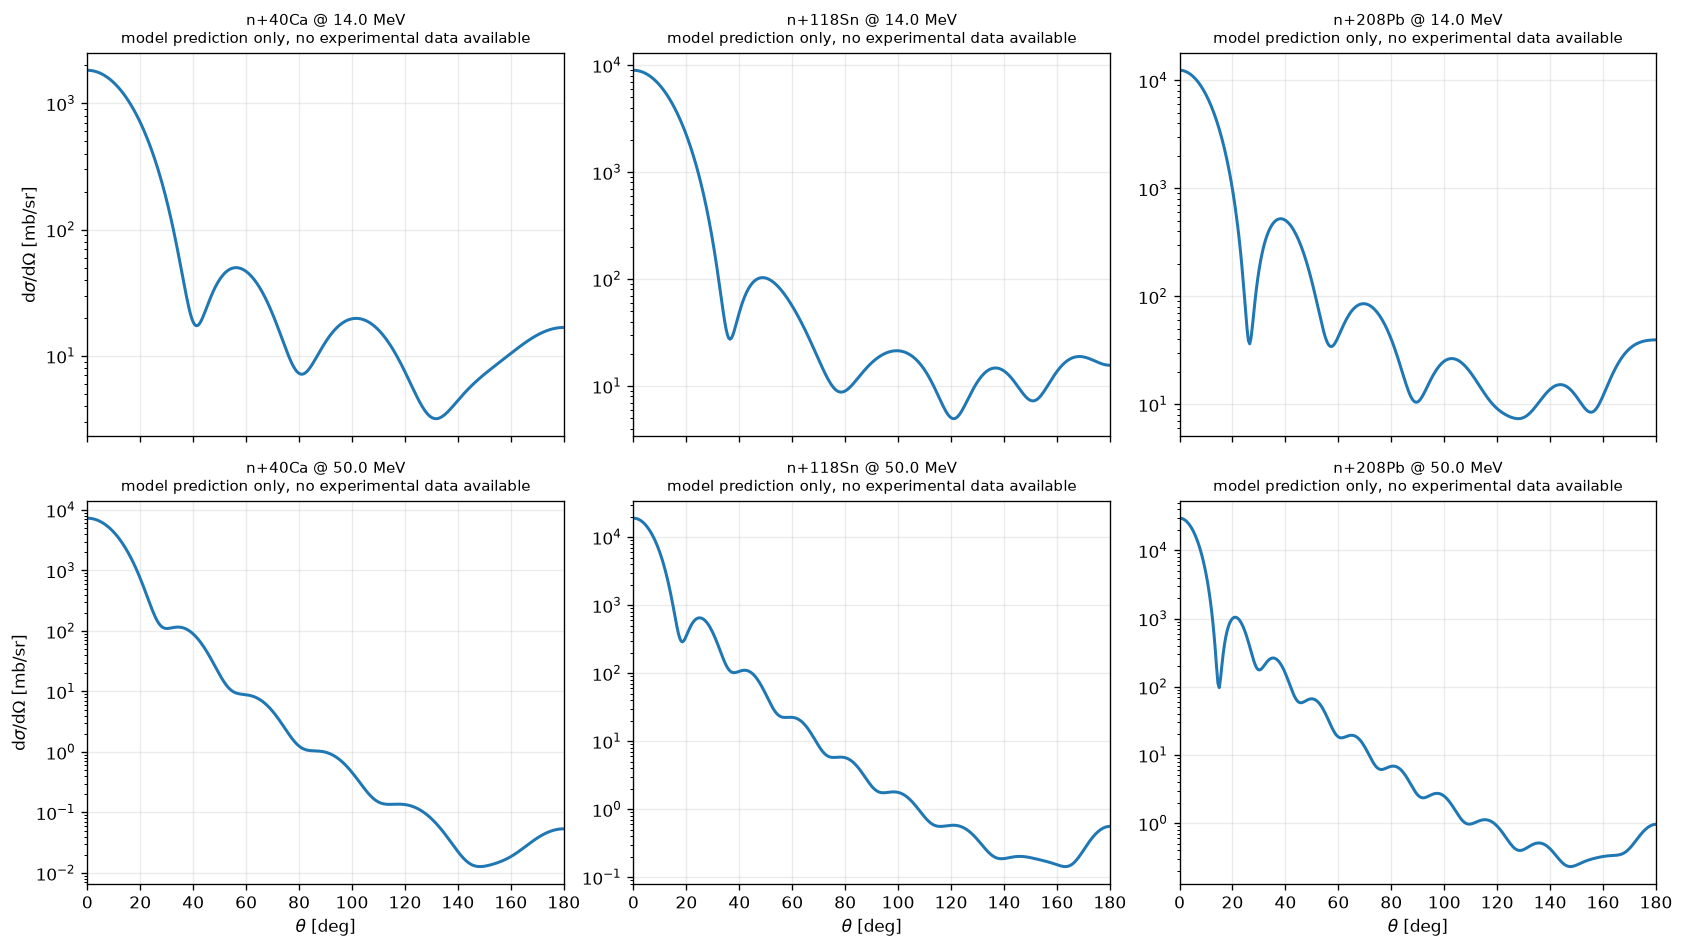

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14.0, 8.0), sharex=True)
for col, (name, target) in enumerate(TARGETS.items()):
    for row, Elab in enumerate(ENERGIES_MEV):
        ax = axes[row, col]
        dsdo = kd03_results[(name, Elab)].dsdo
        ax.plot(ANGLES_CM_DEG, dsdo, color="tab:blue", lw=1.8)
        ax.set_yscale("log")
        ax.set_xlim(0.0, 180.0)
        ax.set_title(
            f"n+{name} @ {Elab:.1f} MeV\nmodel prediction only, no experimental data available",
            fontsize=9,
        )
        if row == 1:
            ax.set_xlabel(r"$\theta$ [deg]")
        if col == 0:
            ax.set_ylabel(r"d$\sigma$/d$\Omega$ [mb/sr]")
fig.tight_layout()
plt.show()


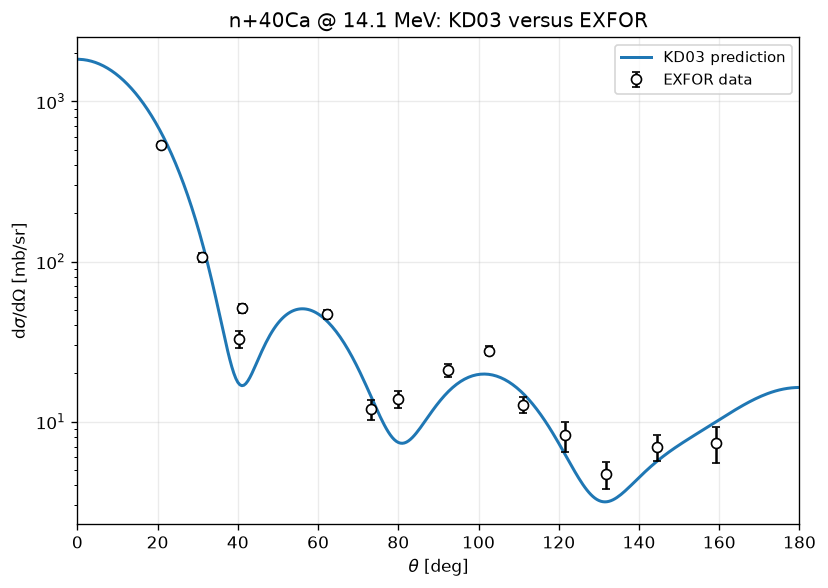

In [7]:
exfor_cos_cm = np.array(
    [
        0.93420, 0.85630, 0.76150, 0.75470, 0.46640, 0.28740, 0.17360,
        -0.0419, -0.2181, -0.3616, -0.5240, -0.6665, -0.8141, -0.9342,
    ]
)
exfor_data_cm = np.array(
    [5.34e2, 1.06e2, 3.27e1, 5.10e1, 4.69e1, 1.20e1, 1.39e1,
     2.09e1, 2.77e1, 1.28e1, 8.2, 4.7, 7.0, 7.4]
)
exfor_data_error = np.array(
    [2.3e1, 7.0, 4.0, 3.5, 2.9, 1.7, 1.7, 2.0, 1.8, 1.4,
     1.7, 0.9, 1.3, 1.9]
)
exfor_angles_cm = np.degrees(np.arccos(exfor_cos_cm))

assert exfor_cos_cm.shape == exfor_data_cm.shape == exfor_data_error.shape == (14,)
assert np.all(np.diff(exfor_angles_cm) > 0.0)

exfor_case_dsdo = kd03_results[(EXFOR_TARGET_NAME, EXFOR_LAB_ENERGY)].dsdo

fig, ax = plt.subplots(figsize=(7.0, 5.0))
ax.plot(ANGLES_CM_DEG, exfor_case_dsdo, color="tab:blue", lw=1.8, label="KD03 prediction")
ax.errorbar(
    exfor_angles_cm,
    exfor_data_cm,
    yerr=exfor_data_error,
    fmt="o",
    mfc="white",
    mec="black",
    ecolor="black",
    capsize=2.5,
    label="EXFOR data",
)
ax.set_yscale("log")
ax.set_xlim(0.0, 180.0)
ax.set_xlabel(r"$\theta$ [deg]")
ax.set_ylabel(r"d$\sigma$/d$\Omega$ [mb/sr]")
ax.set_title(f"n+{EXFOR_TARGET_NAME} @ {EXFOR_LAB_ENERGY} MeV: KD03 versus EXFOR")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
